# Dependency Parsing

This notebook classifies the grammatical role (e.g. active subject, passive subject, direct object, object of a preposition) of each identified natural entity using spaCy's dependency parser.

**Prerequisite:** `setup.ipynb` and `ner_model.ipynb` must be previously executed.

In [15]:
import os
import csv
import random
import spacy
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import numpy as np


NOTEBOOK_DIR = os.path.abspath(os.getcwd())
if os.path.basename(NOTEBOOK_DIR) == "notebooks":
    PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)
else:
    PROJECT_ROOT = NOTEBOOK_DIR

FINAL_ANNOTATION_PATH = os.path.join(PROJECT_ROOT, "data", "annotations", "final_annotation.csv")
INFERRED_PATH = os.path.join(PROJECT_ROOT, "data", "model_predictions", "inferred_entities.csv")
SENTENCE_SCORES_PATH = os.path.join(PROJECT_ROOT, "data", "annotations", "sentence_scores.csv")

OUTPUT_DIR = os.path.join(PROJECT_ROOT, "data", "dependency_analysis")
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_PATH = os.path.join(OUTPUT_DIR, "entity_roles.csv")

FIGURES_DIR = os.path.join(PROJECT_ROOT, "assets", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

SPACY_MODEL_NAME = "en_core_web_trf"
RANDOM_SEED = 42

# loss used for the saved entity_roles.csv
DEP_LABEL_GLOSS = {
    "nsubj": "Active Subject (doing the action)",
    "nsubjpass": "Passive Subject (action done to it)",
    "dobj": "Direct Object (action done to it)",
    "dative": "Indirect Object",
    "pobj": "Object of Preposition",
    "attr": "Attribute (X is a Y)",
    "appos": "Appositive",
    "conj": "Conjoined Element (shares role with another entity)",
    "ROOT": "Root of the sentence",
}

# short display name used for tables
DEP_LABEL_NAME = {
    "nsubj": "Active Subject",
    "nsubjpass": "Passive Subject",
    "dobj": "Direct Object",
    "dative": "Indirect Object",
    "pobj": "Object of Preposition",
    "attr": "Attribute",
    "appos": "Appositive",
    "conj": "Conjoined Element",
    "ROOT": "Root",
}

nlp = spacy.load(SPACY_MODEL_NAME)
print(f"{SPACY_MODEL_NAME} loaded, pipeline:", nlp.pipe_names)

en_core_web_trf loaded, pipeline: ['transformer', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## Load and Combine Entity Sources

Combines both entity sources into one dataset: `final_annotation.csv` and `inferred_entities.csv`.

In [4]:
def load_entities(path, source_label):
    with open(path, newline="", encoding="utf-8") as f:
        rows = list(csv.DictReader(f))
    entities = []
    for row in rows:
        span = row["target_span"].strip()
        if not span:
            continue  # skip sentences with no entity
        entities.append({
            "sentence_id": row["sentence_id"],
            "sentence_text": row["sentence_text"],
            "target_span": span,
            "start_char": int(row["start_char"]),
            "end_char": int(row["end_char"]),
            "entity_type": row["entity_type"],
            "source": source_label,
        })
    return entities


gold_entities = load_entities(FINAL_ANNOTATION_PATH, "gold")
inferred_entities_list = load_entities(INFERRED_PATH, "model")

all_entities = gold_entities + inferred_entities_list
print(f"Gold entities: {len(gold_entities)}")
print(f"Model-predicted entities: {len(inferred_entities_list)}")
print(f"Total entities to analyze: {len(all_entities)}")

Gold entities: 795
Model-predicted entities: 164
Total entities to analyze: 959


## Extract Grammatical Role

For each entity, the sentence is parsed and entity tokens are located using `doc.char_span()`.

For multi-word entities, extraction targets `.root` - the syntactic head of the phrase - since dependency relations operate on individual head tokens rather than entire spans.

In [5]:
def get_entity_role(entity, nlp):
    doc = nlp(entity["sentence_text"])
    span = doc.char_span(entity["start_char"], entity["end_char"], alignment_mode="expand")

    if span is None or len(span) == 0:
        return {"dep": None, "dep_gloss": "COULD NOT LOCATE SPAN", "governing_verb": None}

    root = span.root
    dep = root.dep_
    gloss = DEP_LABEL_GLOSS.get(dep, f"Other ({dep})")

    return {"dep": dep, "dep_gloss": gloss, "governing_verb": root.head.lemma_}


test_cases = [
    {"sentence_text": "The wind swept over the mountain.", "start_char": 4, "end_char": 8},        # wind -> nsubj
    {"sentence_text": "The mountain was struck by lightning.", "start_char": 4, "end_char": 12},    # mountain -> nsubjpass
]
for tc in test_cases:
    result = get_entity_role(tc, nlp)
    print(tc["sentence_text"], "->", result)

The wind swept over the mountain. -> {'dep': 'nsubj', 'dep_gloss': 'Active Subject (doing the action)', 'governing_verb': 'sweep'}
The mountain was struck by lightning. -> {'dep': 'nsubjpass', 'dep_gloss': 'Passive Subject (action done to it)', 'governing_verb': 'strike'}


## Execution Across All Entities

`get_entity_role()` is executed across the entire combined dataset.

In [6]:
results = []
unresolved = 0

for entity in all_entities:
    role = get_entity_role(entity, nlp)
    if role["dep"] is None:
        unresolved += 1

    results.append({
        "sentence_id": entity["sentence_id"],
        "sentence_text": entity["sentence_text"],
        "target_span": entity["target_span"],
        "entity_type": entity["entity_type"],
        "source": entity["source"],
        "dep": role["dep"],
        "dep_gloss": role["dep_gloss"],
        "governing_verb": role["governing_verb"],
    })

print(f"Processed {len(results)} entities")
print(f"  {unresolved} could not be located in their parsed sentence (span mismatch)")

fieldnames = ["sentence_id", "sentence_text", "target_span", "entity_type",
              "source", "dep", "dep_gloss", "governing_verb"]

with open(OUTPUT_PATH, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(results)

print(f"\nWrote entity_roles.csv")

Processed 959 entities
  0 could not be located in their parsed sentence (span mismatch)

Wrote entity_roles.csv


## Verifying `trf`'s Reliability

Due to the absence of gold-standard annotations for this corpus, parser agreement between `en_core_web_trf` and `en_core_web_sm` across all entities is used as a proxy for parsing uncertainty. Disagreements highlight complex syntactic structures and prioritize candidates for manual review.

Of the resulting disagreements, only those involving a core role (`nsubj`, `nsubjpass`, `dobj`, `pobj`) affect the agent/patient analysis - the rest (appositives, compounds, etc.) are filtered out below.

In [7]:
nlp_sm = spacy.load("en_core_web_sm")

agreements = 0
disagreements = []

for entity, result in zip(all_entities, results):
    if result["dep"] is None:
        continue
    doc_sm = nlp_sm(entity["sentence_text"])
    span_sm = doc_sm.char_span(entity["start_char"], entity["end_char"], alignment_mode="expand")
    if span_sm is None or len(span_sm) == 0:
        continue

    dep_sm = span_sm.root.dep_
    dep_trf = result["dep"]

    if dep_sm == dep_trf:
        agreements += 1
    else:
        disagreements.append({**entity, "dep_trf": dep_trf, "dep_sm": dep_sm})

total_compared = agreements + len(disagreements)

CORE_ROLES = {"nsubj", "nsubjpass", "dobj", "pobj"}
core_disagreements = [d for d in disagreements if d["dep_trf"] in CORE_ROLES or d["dep_sm"] in CORE_ROLES]

print(f"Agreement: {agreements}/{total_compared} ({100*agreements/total_compared:.1f}%)")
print(f"Disagreements: {len(disagreements)} total, {len(core_disagreements)} involve a core role (worth reviewing)")

Agreement: 805/959 (83.9%)
Disagreements: 154 total, 120 involve a core role (worth reviewing)


## Manual Adjudication Sampling

**Result: `en_core_web_trf` correct in 13/20 sampled cases (65%) vs. 2/20 (10%) for `en_core_web_sm`.**

A reproducible random sample (n=20, fixed seed) is drawn from the core-role disagreements for manual adjudication.

In [8]:
random.seed(RANDOM_SEED)
SAMPLE_SIZE = 20
sample = random.sample(core_disagreements, SAMPLE_SIZE)

# "trf_partial"/"sm_slight" = got the general shape right (e.g. correctly  identifying "subject") without being fully precise
ADJUDICATION = {
    0:  ("trf",         "object of 'of' in 'caverns of rain', not a subject"),
    1:  ("trf",         "'the white foam flew' - foam is the subject"),
    2:  ("tie",         "archaic postposed preposition - sm confidently wrong, trf non-committal"),
    3:  ("trf",         "'their pines groan' - pines is the subject"),
    4:  ("both_wrong",  "'sea-blooms...know Thy voice' - should be Active Subject"),
    5:  ("trf_partial", "inverted passive, should be Passive Subject; trf got 'subject' right, sm didn't"),
    6:  ("trf",         "'the moonlight lay' - clearly the subject"),
    7:  ("trf",         "elliptical simile, hoar-frost is subject of spread"),
    8:  ("trf",         "'the breeze blew' - clearly the subject"),
    9:  ("sm_slight",   "plain noun object of 'on' - pobj is standard, trf's pcomp imprecise"),
    10: ("tie",         "linking verb, should be Attribute; neither label fully right"),
    11: ("sm",          "'the Sun did stand' - clearly subject; trf failed to classify"),
    12: ("trf",         "nominative absolute, trf reasonably treats as subject-like"),
    13: ("trf",         "listed among things followed/caught - Direct Object is reasonable"),
    14: ("trf",         "'in the wilderness' - clearly object of 'in'"),
    15: ("trf",         "archaic inversion, thunder is subject despite word order"),
    16: ("trf",         "passive agent phrase, object of 'by'"),
    17: ("sm",          "steep is a noun here (object of prep); trf wrongly tagged as adjective"),
    18: ("trf",         "clearly object of 'over'"),
    19: ("trf",         "'Winds contend' - clearly the subject"),
}

print(f"{'#':3s} {'span':16s} {'trf':22s} {'sm':22s} {'verdict':12s} reason")
for i, d in enumerate(sample):
    verdict, reason = ADJUDICATION[i]
    trf_label = DEP_LABEL_NAME.get(d["dep_trf"], d["dep_trf"])
    sm_label = DEP_LABEL_NAME.get(d["dep_sm"], d["dep_sm"])
    print(f"{i:<3d} {d['target_span'][:15]:16s} {trf_label:22s} {sm_label:22s} {verdict:12s} {reason}")

tally = Counter(v[0] for v in ADJUDICATION.values())
print(f"\ntrf correct: {tally['trf']}/20 ({100*tally['trf']/20:.0f}%)   "
      f"sm correct: {tally['sm']}/20 ({100*tally['sm']/20:.0f}%)")

#   span             trf                    sm                     verdict      reason
0   rain             Object of Preposition  Active Subject         trf          object of 'of' in 'caverns of rain', not a subject
1   foam             Active Subject         compound               trf          'the white foam flew' - foam is the subject
2   crags            dep                    Active Subject         tie          archaic postposed preposition - sm confidently wrong, trf non-committal
3   pines            Active Subject         compound               trf          'their pines groan' - pines is the subject
4   sea-blooms       Direct Object          Object of Preposition  both_wrong   'sea-blooms...know Thy voice' - should be Active Subject
5   dews             Active Subject         Direct Object          trf_partial  inverted passive, should be Passive Subject; trf got 'subject' right, sm didn't
6   moonlight        Active Subject         compound               trf          'the m

## Grammatical Role Distribution by Entity Type

Dependency roles are cross-tabulated against entity categories to measure grammatical agency. This distinguishes categories acting as active agents (active subjects) from those acting as circumstantial context (objects of prepositions).

In [14]:
type_dep_counts = defaultdict(Counter)
for r in results:
    if r["dep"]:
        type_dep_counts[r["entity_type"]][r["dep"]] += 1

entity_types = ["NATURE", "WEATHER", "FAUNA", "FLORA", "LANDSCAPE"]
summary_path = os.path.join(OUTPUT_DIR, "role_by_type.csv")

print(f"{'Entity Type':<12} | {'Total':>5} | {DEP_LABEL_NAME['nsubj']:>20} | {DEP_LABEL_NAME['nsubjpass']:>15} | {DEP_LABEL_NAME['dobj']:>14} | {DEP_LABEL_NAME['pobj']:>22}")
print("-" * 100)

rows_to_export = []
for etype in entity_types:
    counts = type_dep_counts[etype]
    total = sum(counts.values()) or 1
    
    nsubj_cnt, nsubj_pct = counts["nsubj"], (100 * counts["nsubj"] / total)
    pobj_cnt, pobj_pct = counts["pobj"], (100 * counts["pobj"] / total)
    
    nsubj_str = f"{nsubj_cnt} ({nsubj_pct:.0f}%)"
    pobj_str = f"{pobj_cnt} ({pobj_pct:.0f}%)"
    
    print(f"{etype:<12} | {total:>5d} | {nsubj_str:>20} | {counts['nsubjpass']:>15d} | {counts['dobj']:>14d} | {pobj_str:>22}")
    
    rows_to_export.append([
        etype, total,
        nsubj_cnt, round(nsubj_pct, 1),
        counts["nsubjpass"],
        counts["dobj"],
        pobj_cnt, round(pobj_pct, 1)
    ])

with open(summary_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow([
        "entity_type", "total",
        DEP_LABEL_NAME["nsubj"], f"{DEP_LABEL_NAME['nsubj']} %",
        DEP_LABEL_NAME["nsubjpass"],
        DEP_LABEL_NAME["dobj"],
        DEP_LABEL_NAME["pobj"], f"{DEP_LABEL_NAME['pobj']} %",
    ])
    writer.writerows(rows_to_export)

print(f"\nWrote role_by_type.csv")

Entity Type  | Total |       Active Subject | Passive Subject |  Direct Object |  Object of Preposition
----------------------------------------------------------------------------------------------------
NATURE       |    55 |             16 (29%) |               1 |              7 |               11 (20%)
WEATHER      |   394 |            128 (32%) |               7 |             31 |              145 (37%)
FAUNA        |    59 |             15 (25%) |               1 |             13 |               11 (19%)
FLORA        |    87 |             13 (15%) |               2 |              8 |               43 (49%)
LANDSCAPE    |   364 |             65 (18%) |               1 |             27 |              182 (50%)

Wrote role_by_type.csv


## Visualizing Grammatical Role by Entity Type

Chart the headline finding directly - NATURE and FAUNA are the only two categories where Active Subject exceeds Object of Preposition; FLORA and LANDSCAPE show the clearly opposite pattern.

Wrote roles_by_type.png


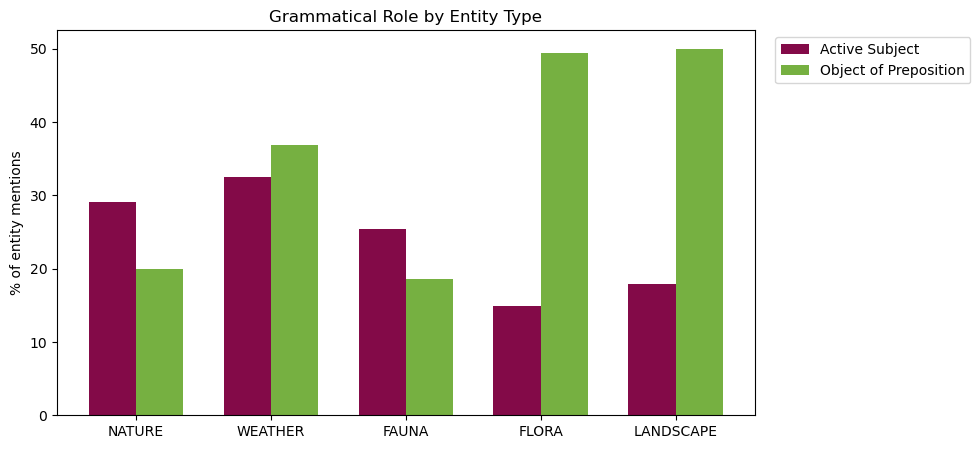

In [13]:
nsubj_pcts = [100 * type_dep_counts[t]["nsubj"] / sum(type_dep_counts[t].values()) for t in entity_types]
pobj_pcts = [100 * type_dep_counts[t]["pobj"] / sum(type_dep_counts[t].values()) for t in entity_types]

x = np.arange(len(entity_types))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, nsubj_pcts, width, label="Active Subject", color="#830A48")
ax.bar(x + width/2, pobj_pcts, width, label="Object of Preposition", color="#76B041")
ax.set_ylabel("% of entity mentions")
ax.set_title("Grammatical Role by Entity Type")
ax.set_xticks(x)
ax.set_xticklabels(entity_types)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))

chart_path = os.path.join(FIGURES_DIR, "roles_by_type.png")
fig.savefig(chart_path, dpi=150, bbox_inches="tight")
print(f"Wrote roles_by_type.png")
plt.show()